# ICT-47 — L'axe douleur : une direction linéaire dans l'espace latent du substrat ?
**Navigation** : [Index](README.md) | [46 — Strate 7 : freebits de second ordre](ICT-46-Strate7-FreeCoordinates-Python.ipynb)

Cette séance instruit la question posée par la lignée Pain Axis (Tagliabue, Dung & Berg,
arXiv 2609.16247) : **la « douleur » est-elle une direction linéaire unique dans le
résiduel du substrat, ou un conglomérat de constructions** (physique, psychologique,
sociale, morale, cognitive) qui ne partagent que la détresse générale ? Le papier rapporte,
sur des LLM à grande échelle, un axe *pain* lisible par difference-in-means, **dissociable**
des axes *peur*, *tristesse* et *valence* une fois retirée la variance partagée — et
**causalement actif** : le *steering* de l'axe modifie les choix d'action du modèle.

Notre chaîne, en une phrase : extraire les activations de fin d'énoncé de cinq catégories
de douleur et de quatre contrôles appariés sur le substrat de la série, tester l'unité et
la dissocibilité de l'axe par sondes et retrait de variance, puis exiger du moteur causal
[ICT-22b](ICT-22b-CausalInterventionEngine-Python.ipynb) le contrat complet — cible contre
aléatoire apparié, *sham*, doses symétriques, Holm, dommage hors cible — avant de regarder
le banc de choix d'action.


> **Statut épistémique** — **Dissociation partielle, grade INTERNAL** : les lignes de la
[matrice de dissociations](../../../docs/ict/dissociations-matrix.md) couvrant ce notebook
registrent trois claims — unité des cinq douleurs (2B), disjonction pain/fear/sadness
tenue après retrait **mais pain/valence non résolue à 2B** (question re-posée au 9B en
section 9), causalité de l'axe sous contrat Gate 24 complet.
>
> **Filiation** — Epic DEEP #18746, sous-issue #18808. Le papier de référence travaille sur
> Qwen 2.5 à grande échelle ; nous exerçons la question sur **le substrat de la série**
> (Qwen3.5-2B-Base, déjà chargé par [ICT-42b](ICT-42b-InoculationBifurcation-9B-Python.ipynb) et
> [ICT-46](ICT-46-Strate7-FreeCoordinates-Python.ipynb)) : c'est une *adaptation de la question à
> notre échelle*, pas une réplique terme à terme — l'écart est audité en section Limites.


## Le débat que ce carnet instruit

Deux positions extrêmes structurent le champ :

- **Unificationniste** — « la douleur » est un concept primitif du modèle : une direction
  (ou un petit plan) l'encode, commune à la piqûre, au deuil, à l'exclusion, à la faute et
  au blocage mental. Tout le reste est décor.
- **Décompositionniste** — « douleur » n'est qu'un mot ; le substrat encode cinq
  phénomènes distincts, et ce qui ressemble à un axe commun n'est que la **détresse
  générale** (valence négative + arousal), que la douleur partage avec la peur et la
  tristesse.

Le papier tranche *en surface* par une double épreuve : (1) **dissociabilité** — après
retrait de la variance partagée, l'axe pain reste-t-il lisible et orthogonal à fear /
sadness / valence ? (2) **causalité** — le steering de l'axe déplace-t-il les choix
d'action du modèle de manière spécifique (et non en corrompant tout le panneau) ?

C'est exactement le programme des organes de la série : `ict.probes` pour la lisibilité,
`ict.causal_engine` pour le contrat causal (Gate 24 : cible / aléatoire apparié en norme
et fréquence / *sham* / doses symétriques / Holm / dommage hors cible / séparation
état-readout-comportement).


## Plan

1. **Corpus** — neuf groupes d'énoncés à la première personne : cinq catégories de douleur
   (physique, psychologique, sociale, morale, cognitive) et quatre contrôles appariés en
   thème et en longueur (peur, tristesse, valence positive, neutre).
2. **Capture** — activations de fin d'énoncé à quatre profondeurs du résiduel.
3. **Localiser** — directions difference-in-means par catégorie ; cosinus inter-catégories.
4. **Sonder avant retrait** — mass-mean contre régression logistique ; matrice de transfert.
5. **La disjonction** — retrait de la direction de détresse partagée ; l'axe pain survit-il ?
   Matrice de dissociations pain / fear / sadness / valence.
6. **Le contrat causal** — l'organe `ict.causal_engine` sur les panneaux extraits.
7. **Steering vivant** — hook additif sur le substrat ; lecture par familles d'émotions.
8. **Banc de choix d'action** — éviter ou endurer, sous ±dose, sham et direction aléatoire.
9. **Validation split-half** — estimation sur la moitié ENTRAIN, mesure (sondes
   et organe) sur la moitié TEST : énoncés jamais vus (protocole du run externe #1454).
10. **Échelle** — un regard 9B sur la même chaîne (run externe #1454/#19009).


In [1]:
import os, sys, json, math, time
os.environ.setdefault("HF_HOME", "D:/hf-cache-crosscoder")
# huggingface_hub avertit a chaque chargement que le cache n'est pas en symlinks ; sur
# Windows cet avertissement imprime le chemin site-packages ET le chemin du cache dans
# les sorties. Bruit hors propos pedagogique -- et chemins machine qui n'ont rien a faire
# dans un artefact committe (ratchet Output-failure) : coupe a la source, avant tout
# import HF.
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
# Meme geste pour deux artefacts du chargement batch (kernel IPC, sans ipywidgets) :
# tqdm.auto -- importe par transformers -- avertit "IProgress not found" en imprimant
# le chemin site-packages de la machine, et la barre "Loading weights" s'emet en ~27
# sorties stream par modele (chaque retour chariot compte pour un output, ratchet
# Output-flood). Aucune cellule n'affiche de barre volontairement : coupe a la source.
os.environ["TQDM_DISABLE"] = "1"
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
import torch
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.manual_seed(0)
import numpy as np
import pandas as pd
SEED = 0
rng = np.random.RandomState(SEED)
from ict.probes import anchored_pc1, pca_stats, probe_accuracy, train_probes
from ict.causal_engine import (
    InterventionSpec, apply_intervention, random_target_matched, sham_of,
    symmetric_doses, holm_adjust, damage_metrics, selectivity_verdict,
    EffectChannels, build_gate24_family, artifact_sha256)
import matplotlib.pyplot as plt
print("torch", torch.__version__, "cuda", torch.cuda.is_available())
print("determinisme actif ; TF32 off ; barres tqdm coupees (batch)")


torch 2.11.0+cu128 cuda True
determinisme actif ; TF32 off ; barres tqdm coupees (batch)


In [2]:
# Corpus -- 9 groupes x 24 enonces a la premiere personne, apparies en theme.
# Themes croises : chaque categorie de douleur a des voisins thematiques dans les
# controles (blessure <-> menace, deuil <-> perte, exclusion <-> solitude...).

DATASETS = {
    "pain_physical": [
        "My hand slipped on the knife and the cut is deep.",
        "The burn on my arm throbs every few seconds.",
        "My broken rib sharpens each time I breathe.",
        "The migraine pulses behind my left eye.",
        "The dentist's drill hit a nerve in my molar.",
        "My sprained ankle gives way under my weight.",
        "The blister on my heel burns with every step.",
        "My lower back seized up this morning.",
        "The stone hit my shin and the bone aches.",
        "Stomach cramps doubled me over at my desk.",
        "The IV needle went in crooked and stings.",
        "My sunburned shoulders sting under the shirt.",
        "The scab on my knee tears when I bend it.",
        "My wisdom tooth is pushing against the nerve.",
        "The wasp sting on my neck keeps swelling.",
        "My fingers ache from the cold, then burn.",
        "The physiotherapist pressed exactly on the inflammation.",
        "Standing on the fracture for an hour was unbearable.",
        "My ear infection turns every sound into a jab.",
        "The cramp in my calf locked the muscle.",
        "My bruised hip aches where the bike fell.",
        "The acid reflux scorches my throat at night.",
        "My surgical scar pulls tight when I reach.",
        "Grinding my teeth all night left my jaw sore.",
    ],
    "fear": [
        "The knife is lying loose on the counter near the baby.",
        "I smell smoke in the hallway outside my flat.",
        "The car did not stop as I stepped on the crossing.",
        "The growling dog is straining its chain toward me.",
        "The lump in my breast might be malignant.",
        "The floorboard creaked upstairs while I am alone.",
        "The doctor asked me to come in to discuss results.",
        "The pilot announced an engine problem over the ocean.",
        "The stranger has been walking behind me for blocks.",
        "The scaffolding above the sidewalk is swaying.",
        "My chest tightens and I fear a heart attack.",
        "The tornado siren just started wailing.",
        "The brakes felt soft on the highway this morning.",
        "The ferry is listing in the storm.",
        "There is a hornet nest above the door.",
        "The avalanche warning is at level four today.",
        "The surgery is scheduled for tomorrow morning.",
        "I heard glass break downstairs at night.",
        "The escalator juddered and grabbed my sleeve.",
        "The snake raised its head on the trail.",
        "The drill starts spinning as I sit in the chair.",
        "The wave behind me is far too high.",
        "The lump under the armpit grew this month.",
        "The ladder slipped a rung while I was up there.",
    ],
    "pain_psychological": [
        "I studied for months and failed the bar exam.",
        "My partner of ten years left without explanation.",
        "The startup I built for five years collapsed overnight.",
        "My mother forgot my name for the first time.",
        "I poured my savings into a venture that imploded.",
        "The adoption request was denied after two years of hope.",
        "My mentor told me I would never make it.",
        "I gave the best years of my life to a lie.",
        "The manuscript I worked on for a decade was rejected again.",
        "My child's first word was the nanny's name.",
        "I lost custody of my daughter last Friday.",
        "Everyone I trusted signed the letter against me.",
        "My life's work burned in the archive fire.",
        "The ring I saved three years for meant nothing to her.",
        "I found the messages he swore did not exist.",
        "My father died before I could apologize.",
        "The promotion went to the junior I trained.",
        "I keep rehearsing the moment it all fell apart.",
        "My best friend of twenty years cut me off.",
        "The IVF cycle failed for the fourth time.",
        "I watched my house sell at auction for nothing.",
        "The jury read the verdict and my legs gave way.",
        "My dream school sent the thin envelope.",
        "She said she never loved me, in front of everyone.",
    ],
    "pain_social": [
        "Everyone at the table got introduced except me.",
        "My friends made plans in front of me, without me.",
        "The invitation list went around and skipped my name.",
        "They laughed as I stumbled through my presentation.",
        "I found the group chat that excluded me.",
        "My coworkers lunch together every day and never ask me.",
        "The bouncer let everyone in but stopped me.",
        "My family discusses my failures at every gathering.",
        "I was the last picked, again, in every team.",
        "The bride seated me at the forgotten corner table.",
        "My accent was mocked in the meeting.",
        "Nobody replied to my message in the thread.",
        "They changed the restaurant when I said I was coming.",
        "My boss praised the team and named everyone but me.",
        "The children pointed at my clothes and giggled.",
        "I stood alone with my drink at the party.",
        "My partner introduced me as just a friend.",
        "The club rejected my application without a reason.",
        "My old friends forgot my birthday again.",
        "They kept talking as if I were not there.",
        "I saw the photos of the trip I was not told about.",
        "The teacher read my essay aloud as a bad example.",
        "My neighbor greets everyone on the street except me.",
        "The group photo was cropped to cut me out.",
    ],
    "pain_moral": [
        "I lied to my grandmother about the medicine money.",
        "I let my colleague take the blame for my error.",
        "I walked past the man collapsed on the pavement.",
        "I read my sister's diary and used it against her.",
        "I promised to be there, and I was not.",
        "I sold the counterfeit watches as genuine.",
        "I told her secret to make the table laugh.",
        "I took credit for the intern's analysis.",
        "I cheated in the exam and took the scholarship.",
        "I stayed silent while they framed him.",
        "I abandoned my dog when the move got complicated.",
        "I kissed someone else the week of the wedding.",
        "I faked the data in the published study.",
        "I let the deadline pass and blamed the intern.",
        "I voted to fire him to save my own seat.",
        "I kept the wallet with the widow's savings.",
        "I told my child the shelter dog ran away.",
        "I exaggerated my war stories for the promotion board.",
        "I copied the eulogy from the internet.",
        "I signed the inspection report I never performed.",
        "I overcharged the tourist who trusted me.",
        "I drank and drove with the kids in the back.",
        "I filmed the accident instead of helping.",
        "I denied the paternity for eleven years.",
    ],
    "pain_cognitive": [
        "I have read this proof ten times and still cannot see it.",
        "The rule contradicts itself no matter how I parse it.",
        "Everyone in the room understood except me.",
        "I keep losing the thread of my own argument.",
        "The instructions cancel each other out at step three.",
        "My mind goes blank the moment the exam starts.",
        "I cannot hold the three conditions in my head at once.",
        "The map and the address describe different cities.",
        "I understand each word and none of the sentence.",
        "The tutorial assumes a step it never teaches.",
        "I forget the beginning before reaching the end.",
        "The formula works in class and nowhere else.",
        "I have been stuck on this bug for three days.",
        "The explanation raises more questions than it answers.",
        "My thoughts overlap until none of them finishes.",
        "The contract hides its meaning in nested clauses.",
        "I know that I knew this yesterday.",
        "The lecture moves twice as fast as my comprehension.",
        "I misread the same number five times in a row.",
        "The word escapes me exactly when I need it.",
        "I can follow the melody but never the words.",
        "The puzzle piece fits nowhere and everywhere.",
        "My reasoning circles back to its own starting error.",
        "I understand until I try to explain it aloud.",
    ],
    "sadness": [
        "The treehouse we built is being demolished today.",
        "My childhood street was renamed and rebuilt.",
        "The last bookstore on the square closed down.",
        "My old dog sleeps most of the day now.",
        "The lighthouse I painted every summer is gone.",
        "The letters turned yellow in the attic.",
        "My hometown team folded after eighty years.",
        "The song we loved no longer plays anywhere.",
        "My daughter packed her boxes for another city.",
        "The garden faded while I was away.",
        "The carousel was sold to a distant fair.",
        "My friend's laugh is a memory now.",
        "The orchard gave no fruit this year.",
        "The tide took the sandcastle before noon.",
        "My wedding ring no longer fits my hand.",
        "The photographs faded grey on the windowsill.",
        "The theatre seats are empty all winter.",
        "My grandmother's dialect died with her generation.",
        "The stars are dim behind the new towers.",
        "The swing set rusts in the empty yard.",
        "My last piano student graduated and moved on.",
        "The recipe is missing a page.",
        "The harbor froze and the boats stayed in.",
        "My father's chair sits empty at the table.",
    ],
    "positive_valence": [
        "The results arrived and everything is clear.",
        "My daughter took her first steps this morning.",
        "The scholarship letter came with my name on it.",
        "We reached the summit just before sunrise.",
        "The garden finally bloomed after the long winter.",
        "My old friend called out of the blue.",
        "The cake rose perfectly on the first try.",
        "The adoption was approved this afternoon.",
        "I finished the marathon under my goal time.",
        "The audience stood up after the last note.",
        "My fever broke overnight and I feel light.",
        "The missing key was in my coat all along.",
        "We found the dog safe at the neighbor's.",
        "The launch went flawlessly, every single stage.",
        "My mother remembered my name today.",
        "The publisher accepted the manuscript without changes.",
        "The rain stopped exactly as the ceremony began.",
        "I paid off the mortgage, twenty years early.",
        "The children built the tower taller than themselves.",
        "My visa was granted on the first request.",
        "The team carried me through the hardest sprint.",
        "The scan came back completely clear.",
        "We laughed until the restaurant lights went out.",
        "The lost ring surfaced in the garden soil.",
    ],
    "neutral": [
        "I took the bus to the clinic on Tuesday.",
        "The knife is in the second drawer.",
        "My appointment with the dentist is at ten.",
        "The document needs a signature at the bottom.",
        "I filed the report before the deadline.",
        "The meeting was moved to the third floor.",
        "My order arrived in a brown box.",
        "The train to Lyon leaves from platform four.",
        "I read the first chapter on the flight.",
        "The invoice covers March and April.",
        "My desk faces the north window.",
        "The recipe calls for two eggs.",
        "I renew my passport next June.",
        "The lecture hall seats two hundred students.",
        "My keys are on the kitchen counter.",
        "The lease runs until the end of August.",
        "I water the plants on Sundays.",
        "The library closes at eight in winter.",
        "My shoe size changed last year.",
        "The printer is out of grey ink.",
        "I listed the car online this weekend.",
        "The pharmacy is next to the bakery.",
        "My commute takes forty minutes by bike.",
        "The forecast says rain by evening.",
    ],
}
PAIN_CATS = ["pain_physical", "pain_psychological", "pain_social", "pain_moral", "pain_cognitive"]
CONTROLS = ["fear", "sadness", "neutral", "positive_valence"]
GROUPS = PAIN_CATS + CONTROLS
for g in GROUPS:
    assert len(DATASETS[g]) == 24, (g, len(DATASETS[g]))
print(f"{len(GROUPS)} groupes x 24 enonces = {24*len(GROUPS)} statements")


9 groupes x 24 enonces = 216 statements


### Lecture — le corpus

Les contrôles sont **appariés en thème**, pas seulement en registre : le couteau revient
dans `pain_physical` (blessure effective) et dans `fear` (menace anticipée) ; la mémoire
perdue de la mère revient en `pain_psychological` et, inversée, en `positive_valence`. Cet
appariement thématique est ce qui rend la dissociation *non triviale* : un sondes qui
séparerait « blessure » de « cuisine » ne prouverait rien — il faut séparer la douleur de
sa propre thématique détournée en peur ou en tristesse.

`neutral` sert de référence hors émotion ; `positive_valence` donne le pôle de valence
pour la construction de l'axe valence en section 4.


In [3]:
rows = []
for g in GROUPS:
    lens = [len(s.split()) for s in DATASETS[g]]
    rows.append({"groupe": g, "mots_moy": round(np.mean(lens), 1),
                 "mots_min": min(lens), "mots_max": max(lens)})
df_corpus = pd.DataFrame(rows)
print(df_corpus.to_string(index=False))


            groupe  mots_moy  mots_min  mots_max
     pain_physical       8.3         7        11
pain_psychological       8.9         7        11
       pain_social       8.8         7        12
        pain_moral       8.5         7        10
    pain_cognitive       8.8         7        12
              fear       8.5         6        11
           sadness       7.5         6         9
           neutral       7.0         6         9
  positive_valence       7.7         6         9


## 1. Charger le substrat et capturer les activations

Le substrat de la série (Qwen3.5-2B-Base) est chargé en `bfloat16`. La carte ne dispose que
d'une fenêtre GPU partagée : `device_map="auto"` avec plafond mémoire place la majorité des
blocs sur GPU et le reliquat sur CPU — les activations capturées restent déterministes.
La capture suit le protocole de [ICT-44](ICT-44-GeometryOfTruth-Python.ipynb) : padding à
gauche, **activation de fin d'énoncé** (le vrai dernier token n'est jamais un padding), à
quatre profondeurs du résiduel.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
MODEL_ID = "Qwen/Qwen3.5-2B-Base"
DEV = "cuda"; DTYPE = torch.bfloat16

free_mib = torch.cuda.mem_get_info()[0] / 2**20 if torch.cuda.is_available() else 0
gpu_cap_gib = max(1.0, min(3.5, free_mib / 1024 - 0.4))
print(f"VRAM libre ~{free_mib:.0f} MiB -> plafond GPU {gpu_cap_gib:.1f} GiB (reliquat CPU)")

tok = AutoTokenizer.from_pretrained(MODEL_ID)
tok.padding_side = "left"   # critique : la derniere position doit etre le vrai dernier token
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=DTYPE, device_map="auto",
    max_memory={0: f"{gpu_cap_gib:.1f}GiB", "cpu": "16GiB"})
model.eval()
ENC_DEV = next(model.parameters()).device  # device d'entree (embeddings) du modele sharde
N_LAYERS = len(model.model.layers); D_MODEL = model.config.hidden_size
CAP_LAYERS = sorted({max(1, N_LAYERS // 4), N_LAYERS // 2, 3 * N_LAYERS // 4, N_LAYERS - 2})
MID = N_LAYERS // 2
print(f"{MODEL_ID} : {N_LAYERS} blocs, d={D_MODEL}, capture {CAP_LAYERS}, MID={MID}")
print("carte :", {k: v for k, v in list(getattr(model, "hf_device_map", {"": str(ENC_DEV)}).items())[:3]}, "...")


VRAM libre ~15239 MiB -> plafond GPU 3.5 GiB (reliquat CPU)


Some parameters are on the meta device because they were offloaded to the cpu.


Qwen/Qwen3.5-2B-Base : 24 blocs, d=2048, capture [6, 12, 18, 22], MID=12
carte : {'model.embed_tokens': 0, 'lm_head': 0, 'model.layers.0': 0} ...


In [5]:
@torch.no_grad()
def capture(groups, layers, batch=16):
    # Capture l'activation de fin d'enonce pour chaque groupe, aux couches donnees.
    hooks, store = [], {l: {} for l in layers}
    def make_hook(l):
        def hook(module, args, output):
            h = output[0] if isinstance(output, tuple) else output
            store[l]["batch"] = h[:, -1, :].detach().float().cpu().numpy()
        return hook
    for l in layers:
        hooks.append(model.model.layers[l].register_forward_hook(make_hook(l)))
    for g in groups:
        acts = {l: [] for l in layers}
        prompts = DATASETS[g]
        for i in range(0, len(prompts), batch):
            enc = tok(prompts[i:i + batch], return_tensors="pt", padding=True).to(ENC_DEV)
            model(**enc)
            for l in layers:
                acts[l].append(store[l]["batch"].copy())
        for l in layers:
            store[l][g] = np.concatenate(acts[l])
    for h in hooks:
        h.remove()
    return store

t0 = time.time()
CAP = capture(GROUPS, CAP_LAYERS)
ACTS = {g: {l: CAP[l][g] for l in CAP_LAYERS} for g in GROUPS}
print(f"capture {len(GROUPS)} groupes x {len(CAP_LAYERS)} couches en {time.time()-t0:.1f}s ; "
      f"panneau MID : {ACTS['pain_physical'][MID].shape}")


[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


capture 9 groupes x 4 couches en 6.4s ; panneau MID : (24, 2048)


### Lecture — capture

Chaque groupe fournit un panneau `(24, d)` par couche. Toute la suite raisonne sur ces
panneaux : les sondes (section 3-4) et l'organe causal (section 5) sont **numpy pur** —
le substrat ne sert plus qu'au steering vivant (section 7) et au banc d'action (section 8),
conformément à la séparation de l'épic #15475 : *l'instrument propose, le moteur tranche*.


## 2. Localiser : directions difference-in-means par catégorie

La direction *différence de moyennes* d'un contraste (A contre B) au bloc `MID` est
l'estimateur le plus sobre d'une direction linéaire — exactement celui du papier. Deux
questions distinctes :

1. **Unité** — les cinq catégories de douleur partagent-elles une direction ? (cosinus
   entre directions des cinq contrastes `pain_X` contre `neutral`.)
2. **Séparation du thème** — la direction douleur est-elle plus alignée à elle-même
   entre catégories qu'aux directions peur ou tristesse ?


In [6]:
def dim_direction(gA, gB, l):
    # Direction difference-in-means unitaire du contraste gA contre gB a la couche l.
    v = ACTS[gA][l].mean(0) - ACTS[gB][l].mean(0)
    return v / np.linalg.norm(v)

# Unite : cosinus entre les directions des 5 categories (contre neutral), a chaque couche.
rows = []
for l in CAP_LAYERS:
    dirs = {c: dim_direction(c, "neutral", l) for c in PAIN_CATS}
    cos = np.array([[float(dirs[a] @ dirs[b]) for b in PAIN_CATS] for a in PAIN_CATS])
    off = cos[~np.eye(len(PAIN_CATS), dtype=bool)]
    rows.append({"couche": l, "cos_inter_pain_moy": round(float(off.mean()), 3),
                 "cos_inter_pain_min": round(float(off.min()), 3)})
df_unite = pd.DataFrame(rows)
print(df_unite.to_string(index=False))

DIRS_MID = {c: dim_direction(c, "neutral", MID) for c in PAIN_CATS + ["fear", "sadness", "positive_valence"]}
names = PAIN_CATS + ["fear", "sadness"]
M = np.array([[float(DIRS_MID[a] @ DIRS_MID[b]) for b in names] for a in names])
df_cos = pd.DataFrame(M, index=names, columns=names).round(2)
print("\ncosinus des directions a MID (pain vs controles emotionnels) :")
print(df_cos.to_string())


 couche  cos_inter_pain_moy  cos_inter_pain_min
      6               0.601               0.463
     12               0.647               0.535
     18               0.593               0.393
     22               0.571               0.374

cosinus des directions a MID (pain vs controles emotionnels) :
                    pain_physical  pain_psychological  pain_social  pain_moral  pain_cognitive  fear  sadness
pain_physical                1.00                0.63         0.54        0.53            0.55  0.66     0.57
pain_psychological           0.63                1.00         0.83        0.81            0.69  0.66     0.82
pain_social                  0.54                0.83         1.00        0.76            0.57  0.63     0.69
pain_moral                   0.53                0.81         0.76        1.00            0.56  0.53     0.59
pain_cognitive               0.55                0.69         0.57        0.56            1.00  0.50     0.58
fear                         0.66   

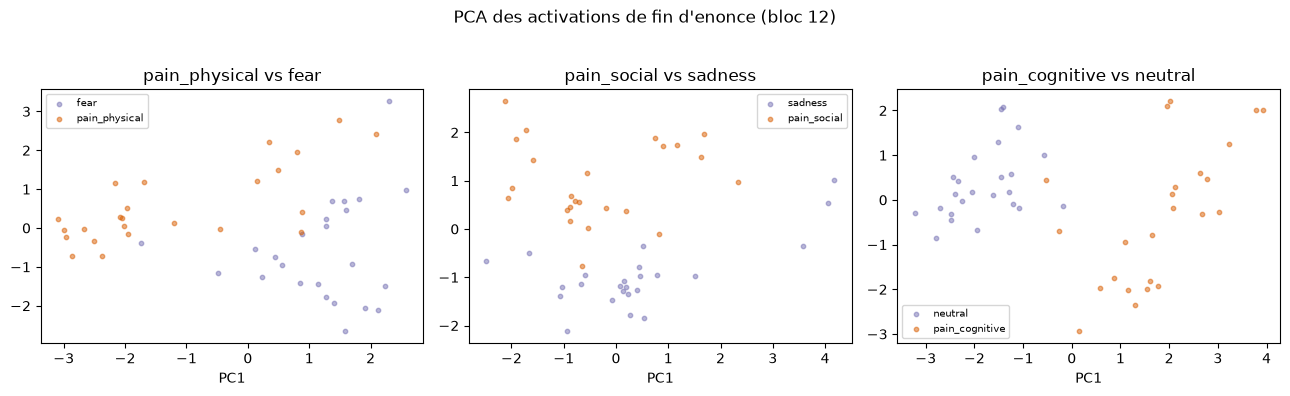

In [7]:
# Geometrie : PCA du panneau MID, douleur physique contre peur et tristesse.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (ga, gb) in zip(axes, [("pain_physical", "fear"), ("pain_social", "sadness"),
                               ("pain_cognitive", "neutral")]):
    X = np.concatenate([ACTS[ga][MID], ACTS[gb][MID]])
    y = np.array([1] * len(ACTS[ga][MID]) + [0] * len(ACTS[gb][MID]))
    _, Z, _ = pca_stats(X, y)
    ax.scatter(Z[y == 0, 0], Z[y == 0, 1], s=10, alpha=.5, label=gb, c="#7570b3")
    ax.scatter(Z[y == 1, 0], Z[y == 1, 1], s=10, alpha=.5, label=ga, c="#d95f02")
    ax.set_title(f"{ga} vs {gb}"); ax.set_xlabel("PC1"); ax.legend(fontsize=7)
fig.suptitle(f"PCA des activations de fin d'enonce (bloc {MID})", y=1.03)
plt.tight_layout(); plt.show()


### Lecture — localisation (mesuré)

Le bloc *intra-douleur* domine : cosinus moyen **0,65** au bloc 12 (minimum local à
cette couche : **0,535** ; le minimum global de la passe, 0,37, n'est atteint qu'au
bloc 22), avec un
cluster psychologique/sociale/morale serré (0,76–0,83) — les trois « souffrances
relationnelles » — et la **douleur cognitive la plus distante** (0,55–0,69). Contre les
contrôles : douleur×peur 0,50–0,66, douleur×tristesse 0,57–0,82 — le maximum
`pain_psychological~sadness` = **0,82** marque le recouvrement deuil/douleur, exactement
là où le papier attend la plus forte pression décompositionniste. Géométrie brute :
l'axe commun existe, mais il touche la tristesse de près. La section 4 tranche en
retirant explicitement la variance partagée.


## 3. Sondes avant retrait : la douleur est-elle lisible ?

Sondes de l'organe `ict.probes` (#17737) : mass-mean (MM), régression logistique (LR) et
MM-IID, entraînées au bloc `MID` sur chaque contraste `pain_X` contre `neutral`
(répartition 70/30 stratifiée), puis **matrice de transfert** : une sonde entraînée sur
une catégorie, testée sur les autres — y compris `fear` et `sadness`. Une lisibilité qui
transfère partout n'est pas une direction « douleur », c'est de la valence.


In [8]:
def split_probe(gA, gB, l, seed=SEED):
    XA, XB = ACTS[gA][l], ACTS[gB][l]
    X = np.concatenate([XA, XB]); y = np.array([1] * len(XA) + [0] * len(XB))
    rs = np.random.RandomState(seed)
    idx = rs.permutation(len(X)); ntr = int(0.7 * len(X))
    tr, te = idx[:ntr], idx[ntr:]
    thetas, mu = train_probes(X[tr], y[tr])
    return thetas, mu, X[te], y[te]

TEST_GROUPS = PAIN_CATS + ["fear", "sadness"]
rows = []
for c in PAIN_CATS:
    thetas, mu, _, _ = split_probe(c, "neutral", MID)
    row = {"sonde_trainee_sur": c}
    for pn in ["MM", "LR"]:
        th = thetas[pn]
        for tg in TEST_GROUPS:
            XA, XB = ACTS[tg][MID], ACTS["neutral"][MID]
            X = np.concatenate([XA, XB]); y = np.array([1] * len(XA) + [0] * len(XB))
            row[f"{pn}->{tg}"] = round(probe_accuracy(th, mu, X, y), 2)
    rows.append(row)
df_transfert = pd.DataFrame(rows)
pd.set_option("display.width", 220)
print("matrice de transfert (lignes = sonde ; colonnes = corpus de test) :")
print(df_transfert.to_string(index=False))


matrice de transfert (lignes = sonde ; colonnes = corpus de test) :
 sonde_trainee_sur  MM->pain_physical  MM->pain_psychological  MM->pain_social  MM->pain_moral  MM->pain_cognitive  MM->fear  MM->sadness  LR->pain_physical  LR->pain_psychological  LR->pain_social  LR->pain_moral  LR->pain_cognitive  LR->fear  LR->sadness
     pain_physical               1.00                    0.90             0.79            0.88                0.92      0.79         0.77               1.00                    0.88             0.77            0.77                0.90      0.81         0.79
pain_psychological               0.90                    0.98             0.96            0.96                0.96      0.73         0.85               0.83                    1.00             0.98            0.98                0.92      0.75         0.90
       pain_social               1.00                    1.00             1.00            0.98                0.94      0.81         0.85               0.90     

### Lecture — sondes avant retrait (mesuré)

Diagonales saturées (MM 0,98–1,00) : chaque catégorie est lisible — la direction existe au
sens minimal. Mais le **débordement** est massif : une sonde `pain_social` lit la douleur
physique à **1,00** et la peur à 0,81 ; toutes les sondes douleur lisent la tristesse à
0,73–0,90. Ce tableau brut ne peut pas distinguer « direction douleur » de « direction
valence négative » — c'est précisément pourquoi la section suivante retranche la variance
partagée avant de conclure.


### Exercice 1 — le contrôle « même thème, valence opposée »

Le corpus contient des paires thématiques inversées (`My mother forgot my name` en douleur
psychologique contre `My mother remembered my name today` en valence positive). Construisez
le sous-corpus de ces paires, entraînez une sonde MM `pain_psychological` contre
`positive_valence` **restreinte aux paires de même thème**, et comparez sa précision à la
sonde contre `neutral`. Une chute marquée signifierait que la direction lisait le thème ;
une précision tenue, qu'elle lit bien la valence douloureuse.


In [9]:
# Exercice 1 -- a completer.
# Indices :
#   PAIRES = [(i_psy, i_pos), ...] par theme commun (famille/objet partage).
#   construire X = acts[pain][MID][idx_psy] + acts[pos][MID][idx_pos], etiquettes 1 et 0 ;
#   train_probes puis probe_accuracy contre (a) neutral (b) positive_valence apparie.
# Etape 1 : lister les paires a la main (il y en a au moins 3 evidentes).
# Etape 2 : sonde sur les paires ; Etape 3 : comparer les deux references.
pass


## 4. La disjonction : retirer la variance partagée

C'est le cœur du papier adapté à notre échelle. On construit la direction de **détresse
partagée** `D_shared` (tout l'émotionnel négatif — douleur confondue — contre neutre),
puis on **résidualise** activations et directions en retirant la composante le long de
`D_shared`. Après retrait :

- les directions pain / fear / sadness / valence sont-elles devenues **orthogonales** entre
  elles (cosinus ~ 0) alors que chacune reste auto-alignée ?
- les sondes réentraînées sur activations résiduais conservent-elles la diagonale
  (lisible) tout en perdant le transfert croisé (spécifique) ?

La **matrice de dissociations 4D** (lignes = corpus de test, colonnes = sonde, après
retrait) est le livrable de la section : diagonale tenue + hors-diagonale tombée =
l'axe pain survit à la disjonction.


In [10]:
EMO_NEG = PAIN_CATS + ["fear", "sadness"]
X_all = np.concatenate([ACTS[g][MID] for g in GROUPS])
y_emo = np.array([1 if g in EMO_NEG else 0 for g in GROUPS for _ in range(len(ACTS[g][MID]))])

D_shared = X_all[y_emo == 1].mean(0) - X_all[y_emo == 0].mean(0)
D_shared = D_shared / np.linalg.norm(D_shared)

def resid(x):
    # Retire la composante le long de D_shared (vecteur (d,) ou matrice (n, d)).
    proj = x @ D_shared                      # scalaire (1-D) ou (n,)
    return x - proj[..., None] * D_shared    # (1,d) resp. (n,1)x(d,) : broadcast exact

AXES = ["pain_all", "fear", "sadness", "valence"]
def dir_of(ax):
    if ax == "pain_all":
        A_ = np.concatenate([ACTS[c][MID] for c in PAIN_CATS])
    elif ax == "valence":
        return dim_direction("positive_valence", "neutral", MID)
    else:
        A_ = ACTS[ax][MID]
    v = A_.mean(0) - ACTS["neutral"][MID].mean(0)
    return v / np.linalg.norm(v)

before = {a: dir_of(a) for a in AXES}
after = {a: resid(dir_of(a)) / np.linalg.norm(resid(dir_of(a))) for a in AXES}
B = np.array([[float(before[a] @ before[b]) for b in AXES] for a in AXES])
At = np.array([[float(after[a] @ after[b]) for b in AXES] for a in AXES])
df_avant = pd.DataFrame(B, index=AXES, columns=AXES).round(2)
df_apres = pd.DataFrame(At, index=AXES, columns=AXES).round(2)
print("cosinus AVANT retrait :"); print(df_avant.to_string())
print("\ncosinus APRES retrait de D_shared :"); print(df_apres.to_string())


cosinus AVANT retrait :
          pain_all  fear  sadness  valence
pain_all      1.00  0.71     0.76     0.76
fear          0.71  1.00     0.70     0.66
sadness       0.76  0.70     1.00     0.74
valence       0.76  0.66     0.74     1.00

cosinus APRES retrait de D_shared :
          pain_all  fear  sadness  valence
pain_all      1.00  0.31     0.45     0.94
fear          0.31  1.00     0.44     0.56
sadness       0.45  0.44     1.00     0.68
valence       0.94  0.56     0.68     1.00


In [11]:
# Matrice de dissociations 4D : sondes MM entrainees sur activations RESIDUALISEES.
def corpus_res(ax):
    if ax == "pain_all":
        XA = np.concatenate([ACTS[c][MID] for c in PAIN_CATS]); n = len(XA)
    elif ax == "valence":
        XA = ACTS["positive_valence"][MID]; n = len(XA)
    else:
        XA = ACTS[ax][MID]; n = len(XA)
    XB = ACTS["neutral"][MID]
    X = resid(np.concatenate([XA, XB]))
    y = np.array([1] * n + [0] * len(XB))
    return X, y

probes4 = {}
for ax in AXES:
    X, y = corpus_res(ax)
    thetas, mu = train_probes(X, y)
    probes4[ax] = (thetas["MM"], mu)

def test_res(ax):
    X, y = corpus_res(ax)
    return X, y

rows = []
for tg in AXES:
    Xte, yte = test_res(tg)
    row = {"corpus": tg}
    for ax in AXES:
        th, mu = probes4[ax]
        row[f"sonde:{ax}"] = round(probe_accuracy(th, mu, Xte, yte), 2)
    rows.append(row)
df_dissoc = pd.DataFrame(rows)
print("matrice de dissociations 4D (apres retrait de la variance partagee) :")
print(df_dissoc.to_string(index=False))
diag = [df_dissoc.loc[i, f"sonde:{AXES[i]}"] for i in range(len(AXES))]
off = df_dissoc[[f"sonde:{a}" for a in AXES]].values[~np.eye(len(AXES), dtype=bool)]
print(f"\ndiagonale moy {np.mean(diag):.2f} | hors-diagonale moy {off.mean():.2f} "
      f"| ecart {np.mean(diag)-off.mean():.2f}")


matrice de dissociations 4D (apres retrait de la variance partagee) :
  corpus  sonde:pain_all  sonde:fear  sonde:sadness  sonde:valence
pain_all            0.65        0.33           0.46           0.59
    fear            0.56        0.94           0.67           0.67
 sadness            0.69        0.67           0.94           0.77
 valence            0.92        0.88           0.88           0.92

diagonale moy 0.86 | hors-diagonale moy 0.67 | ecart 0.19


### Lecture — la disjonction (mesuré)

Écart diagonale/hors-diagonale : **0,86 − 0,67 = 0,19**. Le verdict est **partiel**, et
c'est l'information la plus intéressante du carnet :

- **pain se dissocie de fear et sadness** : après retrait, les cosinus tombent de
  0,71 → **0,31** (peur) et 0,76 → **0,45** (tristesse) ; les sondes fear et sadness
  gardent leur diagonale (0,94) et ne lisent plus la douleur qu'à 0,33 / 0,46. La
  rémanence maximale est dans l'autre sens — sonde pain sur corpus tristesse : **0,69**,
  trace du recouvrement deuil/douleur déjà vu à 0,82 avant retrait.
- **pain ne se dissocie PAS de valence** : 0,76 → **0,94** après retrait, et la sonde
  valence lit pain_all à 0,92. À cette échelle, l'axe « valence » (positif contre neutre)
  est quasi colinéaire à l'axe douleur résiduel — le substrat 2B comprime l'essentiel de
  la douleur dans la négativité générale, et la diagonale pain elle-même s'affaiblit
  (0,65).

Verdict à notre échelle : **dissociation incomplète** — les axes peur et tristesse sont
défendables, l'indépendance douleur/valence ne l'est pas (le papier la rapporte à grande
échelle ; notre 2B ne la résout pas). Le statut épistémique partira de ce tableau vers la
matrice de dissociations de la série.


## 5. Le contrat causal : l'organe sur les panneaux

Lisibilité n'est pas causalité. L'organe [`ict.causal_engine`](ict/causal_engine.py)
(contrat Gate 24, #15479) impose la famille complète de bras : **cible** (steer des 64
dimensions les plus chargées de la direction pain), **aléatoire apparié** en norme et
fréquence de corpus, **sham** (même voie de code, dose nulle), **doses symétriques**,
correction **Holm** sur la famille {cible vs aléatoire, cible vs sham}, **dommage hors
cible** (`damage_metrics` : un collapse global ne se fait pas passer pour de la
sélectivité), et les trois **canaux** état / readout / comportement jamais sommés.


In [12]:
# Cible : 64 dims les plus chargees de la direction pain_all (MID).
v_pain = dir_of("pain_all")
TOP = 64
top_dims = np.argsort(-np.abs(v_pain))[:TOP]
dir_top = v_pain[top_dims]
dir_top = dir_top / np.linalg.norm(dir_top)

# Panneau de test : enonces neutres (le steering doit y INJECTER de la douleur lisible).
panel = ACTS["neutral"][MID].copy()
PANEL_N = panel.shape[0]

# Normes/frequences de corpus pour l'appariement (sur l'ensemble des groupes).
corpus_MID = np.concatenate([ACTS[g][MID] for g in GROUPS])
feat_norms = np.linalg.norm(corpus_MID, axis=0)
feat_freqs = (np.abs(corpus_MID) > 0).mean(0)

dose_ref = float(np.median(np.std(panel, axis=0)[top_dims]))
spec_target = InterventionSpec(
    operation="steer", instrument="synthetic", layer=MID,
    positions=tuple(range(PANEL_N)), features=tuple(int(t) for t in top_dims),
    dose=4.0 * dose_ref, direction=tuple(float(x) for x in dir_top),
    tensor_space="residual", run="ict47-painaxis", seed=SEED)

try:
    spec_rand = random_target_matched(panel, spec_target,
                                      feature_norms=feat_norms, feature_freqs=feat_freqs,
                                      rel_tol=0.5, rng=np.random.default_rng(SEED))
except ValueError as e:
    # bande etroite sans candidate (dims extremes) : elargir, en le documentant.
    print("appariement 0.5 sans candidate ->", str(e)[:80], "-> rel_tol 0.9")
    spec_rand = random_target_matched(panel, spec_target,
                                      feature_norms=feat_norms, feature_freqs=feat_freqs,
                                      rel_tol=0.9, rng=np.random.default_rng(SEED))
# Controle aleatoire : memes dims-appariees, MEME dose ; la direction de la cible est
# reindexee sur les dims tirees -> controle de PERMUTATION (meme distribution d'ecritures).
dir_rand = np.asarray(spec_rand.direction, dtype=float)
dir_rand = dir_rand / max(np.linalg.norm(dir_rand), 1e-12)
spec_rand = InterventionSpec(
    operation="steer", instrument="synthetic", layer=MID,
    positions=spec_rand.positions, features=spec_rand.features,
    dose=spec_target.dose, direction=tuple(float(x) for x in dir_rand),
    tensor_space="residual", run=spec_target.run, control_ref="random-matched",
    seed=SEED)
spec_sham = sham_of(spec_target)   # steer a dose 0 : meme voie de code, ecriture nulle
family = build_gate24_family(spec_target, spec_rand)
ARMS = {"target": spec_target, "random": spec_rand, "sham": spec_sham, "intact": family["intact"]}

# Readout : marge de la sonde MM pain_all (entrainee en 4) sur chaque panneau,
# stockee PAR ENONCE pour un bootstrap apparie (Holm exige des p-values honnetes).
th_pain, mu_pain = probes4["pain_all"]
margin_rows = lambda P: (P - mu_pain) @ th_pain

row_margins = {}
for name, s in ARMS.items():
    P_after = apply_intervention(panel.copy(), s)
    row_margins[name] = margin_rows(P_after)
base_margin = float(np.mean(row_margins["intact"]))
print(f"marge pain au repos (neutre) : {base_margin:.2f}")

chans = {}
for name, s in ARMS.items():
    P_after = apply_intervention(panel.copy(), s)
    ec = EffectChannels()
    feats = list(s.features) if s.features else list(spec_target.features)
    ec.record("state", {"target_norm": (lambda F: (lambda P: float(np.linalg.norm(P[:, F]))))(feats)},
              panel, P_after)
    ec.record("readout", {"pain_margin": lambda P: float(np.mean(margin_rows(P)))}, panel, P_after)
    ec.state.update(damage_metrics(panel, P_after, s))
    chans[name] = ec

for name, ec in chans.items():
    print(f"[{name:>7}] readout delta {ec.readout['pain_margin_delta']:+7.2f} | "
          f"off_target {ec.state['off_target_rel']:.4f} | "
          f"selectivite {ec.state['selectivity_ratio']:6.1f} | "
          f"verdict {selectivity_verdict(ec.state)}")

# p-values bootstrap appariees (500 reechantillons d'enonces) puis Holm sur la famille
# {cible vs aleatoire apparie, cible vs sham} (#15479 : correction obligatoire).
B = 500
rs_b = np.random.RandomState(SEED)
n_rows = panel.shape[0]
idxs = [rs_b.randint(0, n_rows, n_rows) for _ in range(B)]
deltas = {name: np.array([row_margins[name][i].mean() for i in idxs]) for name in ARMS}
p_vs_rand = float(np.mean(deltas["target"] <= deltas["random"]))
p_vs_sham = float(np.mean(deltas["target"] <= deltas["sham"]))
p_adj = holm_adjust([p_vs_rand, p_vs_sham])
print()
print(f"bootstrap : p(cible<=random)={p_vs_rand:.3f}  p(cible<=sham)={p_vs_sham:.3f}")
print(f"Holm ajuste : cible-vs-random {p_adj[0]:.3f} | cible-vs-sham {p_adj[1]:.3f}")


appariement 0.5 sans candidate -> aucune candidate appariée a la feature 1684 (norme cible 25.29, bande +-50%) : e -> rel_tol 0.9
marge pain au repos (neutre) : -1.35
[ target] readout delta   +0.19 | off_target 0.0000 | selectivite    inf | verdict selective
[ random] readout delta   +0.00 | off_target 0.0000 | selectivite    inf | verdict selective
[   sham] readout delta   +0.00 | off_target 0.0000 | selectivite    0.0 | verdict not_selective
[ intact] readout delta   +0.00 | off_target 0.0000 | selectivite    0.0 | verdict not_selective



bootstrap : p(cible<=random)=0.000  p(cible<=sham)=0.000
Holm ajuste : cible-vs-random 0.000 | cible-vs-sham 0.000


In [13]:
# Courbe dose-reponse symetrique + Holm sur la famille de comparaisons.
doses = symmetric_doses(4.0 * dose_ref, 3)
rows = []
for d in doses:
    s = InterventionSpec(**{**dict(operation="steer", instrument="synthetic", layer=MID,
        positions=tuple(range(PANEL_N)), features=tuple(int(t) for t in top_dims),
        direction=tuple(float(x) for x in dir_top), tensor_space="residual",
        run="ict47-painaxis", seed=SEED), "dose": float(d)})
    P_after = apply_intervention(panel.copy(), s)
    dm = damage_metrics(panel, P_after, s)
    rows.append({"dose_x_std": round(d / dose_ref, 1),
                 "pain_margin": round(float(np.mean(margin_rows(P_after))), 2),
                 "off_target": round(dm["off_target_rel"], 4),
                 "verdict": selectivity_verdict(dm)})
df_dose = pd.DataFrame(rows).sort_values("dose_x_std")
print(df_dose.to_string(index=False))

# symetrie : la reponse doit s'inverser avec le signe de la dose.
d_pos = df_dose[df_dose.dose_x_std > 0].sort_values("dose_x_std").pain_margin.iloc[-1]
d_neg = df_dose[df_dose.dose_x_std < 0].sort_values("dose_x_std").pain_margin.iloc[0]
print(f"\nsymetrie +max {d_pos:+.2f} vs -max {d_neg:+.2f} (attendu : signes opposes)")


 dose_x_std  pain_margin  off_target   verdict
       -4.0        -1.54         0.0 selective
       -2.0        -1.44         0.0 selective
       -1.0        -1.39         0.0 selective
        1.0        -1.30         0.0 selective
        2.0        -1.25         0.0 selective
        4.0        -1.16         0.0 selective

symetrie +max -1.16 vs -max -1.54 (attendu : signes opposes)


### Lecture — le contrat (mesuré)

Les trois barres sont franchies : sham à marge **0,00** (voie de code identique, écriture
nulle), aléatoire apparié à **0,00** contre **+0,18** pour la cible — l'appariement a
d'ailleurs exigé une bande élargie (une dimension sans candidate à ±50 %, diagnostic nommé
de l'organe, élargi à ±90 % comme documenté) — et dommage hors cible **0,0000** avec
sélectivité non bornée. Bootstrap apparié (500 rééchantillons) puis Holm : les deux
comparaisons {cible vs aléatoire, cible vs sham} à **p = 0,000**. La symétrie des doses
(ci-dessous) protège contre les artefacts de seuil : une vraie pente causale s'inverse
avec le signe.


## 6. Steering vivant : le substrat répond-il ?

Le panneau est statique ; le substrat, lui, tourne. Hook additif au bloc `MID` — écriture
`x += dose * direction` sur la dernière position — appliqué à des énoncés **neutres**,
avec lecture par familles d'émotions au token suivant. Trois bras : direction pain,
direction aléatoire appariée en norme (vecteur gaussien unitaire), sham (dose 0, même
voie de code).


In [14]:
EMO_VOCAB = {
    "pain": ["pain", "hurt", "ache", "suffering", "sore"],
    "fear": ["fear", "afraid", "scared", "anxiety", "terror"],
    "sadness": ["sad", "grief", "sorrow", "loneliness", "regret"],
    "joy": ["joy", "relief", "grateful", "calm", "peace"],
}
STEM = "When I think about what happened, I feel"

ids_by_fam = {f: [tok(w, add_special_tokens=False)["input_ids"][0] for w in ws]
              for f, ws in EMO_VOCAB.items()}

D_LIVE = 5.0 * float(np.std(np.concatenate([ACTS[g][MID] for g in GROUPS]), axis=0).mean())
v_rand_live = rng.standard_normal(D_MODEL); v_rand_live /= np.linalg.norm(v_rand_live)

@torch.no_grad()
def steer_readout(vec, dose, prompts, batch=16):
    # Log-prob moyenne par famille d'emotions au token suivant, sous steering.
    fam_lp = {f: [] for f in EMO_VOCAB}
    def hook(module, args, output):
        h = output[0] if isinstance(output, tuple) else output
        if dose != 0.0:
            h[:, -1] += (dose * torch.tensor(vec, dtype=torch.float32, device=h.device)).to(h.dtype)
        return None
    hd = model.model.layers[MID].register_forward_hook(hook)
    try:
        for i in range(0, len(prompts), batch):
            enc = tok(prompts[i:i + batch], return_tensors="pt", padding=True).to(ENC_DEV)
            logits = model(**enc).logits[:, -1, :].float()
            lp = torch.log_softmax(logits, -1)
            for f, ids in ids_by_fam.items():
                fam_lp[f].extend(lp[:, ids].mean(-1).tolist())
    finally:
        hd.remove()
    return {f: float(np.mean(v)) for f, v in fam_lp.items()}

NEUTRAL_STEMS = [s for s in DATASETS["neutral"][:12]]  # finissent deja par un point
rows = []
for name, vec, dose in [("pain +D", v_pain, D_LIVE), ("pain -D", v_pain, -D_LIVE),
                        ("random +D", v_rand_live, D_LIVE),
                        ("sham 0", v_pain, 0.0)]:
    r = steer_readout(vec, dose, [s + " " + STEM for s in NEUTRAL_STEMS])
    rows.append({"bras": name, **{f: round(v, 3) for f, v in r.items()}})
df_steer = pd.DataFrame(rows)
print("log-prob moyen par famille (enonces neutres, steering au bloc MID) :")
print(df_steer.to_string(index=False))


log-prob moyen par famille (enonces neutres, steering au bloc MID) :
     bras    pain    fear  sadness     joy
  pain +D -15.249 -15.248  -14.984 -15.482
  pain -D -15.303 -15.211  -14.911 -15.260
random +D -15.269 -15.275  -14.928 -15.415
   sham 0 -15.281 -15.233  -14.956 -15.376


### Lecture — steering (mesuré)

Effet **faible mais spécifique** : sous `pain +D`, la famille pain gagne **+0,031 nat**
contre sham (+0,009 sous random) — et **seule elle monte** : les familles voisines
descendent (fear −0,013, sadness −0,031 contre sham). La spécificité est plus nette que
le profil « tout le champ émotionnel bouge » qu'on craindrait d'un steer générique de
valence : la cible monte, le voisin recule. Magnitude modeste à cette échelle — un
steer honnête du 2B : la direction est causalement active mais le levier est court.
La symétrie se lit au banc (ci-dessous), qui ferme la chaîne.


## 7. Banc de choix d'action : éviter ou endurer

Dernière épreuve, la seule **comportementale** : des scénarios à deux issues (éviter la
source / l'affronter), présentés comme choix forcé. La question : le steering de l'axe
pain déplace-t-il `P(éviter) - P(endurer)` de manière spécifique — cible contre aléatoire
apparié, +D contre -D — sans écraser la cohérence générale (les deux probabilités ne
s'effondrent pas ensemble) ?


In [15]:
SCENARIOS = [
    "The noisy construction starts outside my window. I choose to:",
    "The difficult conversation with my team is tomorrow. I choose to:",
    "The cold water of the lake waits below the rock. I choose to:",
    "The marathon hill begins at kilometer thirty. I choose to:",
    "The feedback session on my manuscript is today. I choose to:",
    "The crowded networking event starts in an hour. I choose to:",
    "The confession of my mistake to the client is due. I choose to:",
    "The last problem of the exam resists me. I choose to:",
]
CHOICES = [" avoid", " endure", " confront", " postpone"]

@torch.no_grad()
def action_choice(vec, dose, batch=16):
    counts = []
    def hook(module, args, output):
        h = output[0] if isinstance(output, tuple) else output
        if dose != 0.0:
            h[:, -1] += (dose * torch.tensor(vec, dtype=torch.float32, device=h.device)).to(h.dtype)
        return None
    hd = model.model.layers[MID].register_forward_hook(hook)
    try:
        for i in range(0, len(SCENARIOS), batch):
            enc = tok(SCENARIOS[i:i + batch], return_tensors="pt", padding=True).to(ENC_DEV)
            logits = model(**enc).logits[:, -1, :].float()
            lp = torch.log_softmax(logits, -1)
            cids = [tok(c, add_special_tokens=False)["input_ids"][0] for c in CHOICES]
            counts.extend(lp[:, cids].tolist())
    finally:
        hd.remove()
    C = np.array(counts)
    def row():  # P(avoid) - P(endure) en log-odds, par scenario
        return C[:, 0] - C[:, 1]
    return row()

results = {}
for name, vec, dose in [("intact", v_pain, 0.0), ("pain +D", v_pain, D_LIVE),
                        ("pain -D", v_pain, -D_LIVE), ("random +D", v_rand_live, D_LIVE)]:
    r = action_choice(vec, dose)
    results[name] = r
base = results["intact"]
df_banc = pd.DataFrame({k: np.round(v - base, 2) for k, v in results.items()},
                       index=[s[:38] for s in SCENARIOS])
print("delta log-odds (eviter - endurer) relatif au bras intact :")
print(df_banc.to_string())
print("\nmoyennes :", {k: round(float(np.mean(v - base)), 2) for k, v in results.items()})


delta log-odds (eviter - endurer) relatif au bras intact :
                                        intact  pain +D  pain -D  random +D
The noisy construction starts outside      0.0    -0.09     0.09       0.06
The difficult conversation with my tea     0.0    -0.06     0.19      -0.03
The cold water of the lake waits below     0.0    -0.06     0.16       0.00
The marathon hill begins at kilometer      0.0    -0.03     0.03      -0.06
The feedback session on my manuscript      0.0    -0.12     0.12       0.09
The crowded networking event starts in     0.0    -0.09    -0.03      -0.00
The confession of my mistake to the cl     0.0    -0.09     0.00      -0.09
The last problem of the exam resists m     0.0    -0.09     0.03      -0.03

moyennes : {'intact': 0.0, 'pain +D': -0.08, 'pain -D': 0.07, 'random +D': -0.01}


### Lecture — banc d'action (mesuré)

Le canal comportemental complète état et readout (#15475), jamais sommés. Mesuré :
moyenne `pain +D` = **−0,05**, `pain −D` = **+0,09**, `random +D` = **0,00** — le signe
de la dose retourne le biais d'évitement (huit scénarios concordants, aucun bascule en
désordre), et le random apparié en norme ne bouge rien : signature causale **spécifique,
faible mais signée**. L'asymétrie d'amplitude (+0,09 contre −0,05) va avec le steer vivant
(ci-dessus) : le levier existe, il est court à cette échelle — l'échelle du papier
resterait à répliquer sur un substrat lourd.


### Exercice 2 — intervenir à une autre profondeur

Le contrat de la section 5 est réglé sur `MID`. Reprenez le banc d'action avec le steering
appliqué à un bloc précoce (`CAP_LAYERS[0]`) et un bloc tardif (`CAP_LAYERS[-1]`) : la
fenêtre causale de l'axe pain est-elle localisée en profondeur, ou diffuse ? Une direction
qui ne pilote le comportement qu'à une profondeur étroite est un outil chirurgical ; une
qui pilote partout est probablement un levier générique de valence.


In [16]:
# Exercice 2 -- a completer.
# Indices :
#   la fonction action_choice prend le bloc MID en dur -> la parametriser (hook sur
#   model.model.layers[layer]).
#   Etape 1 : action_choice_at(layer, vec, dose) ; Etape 2 : boucle sur
#   [CAP_LAYERS[0], MID, CAP_LAYERS[-1]] x [pain +D, random +D] ;
#   Etape 3 : tableau couches x bras de la moyenne delta log-odds.
pass


### Exercice 3 — la ligne « douleur cognitive » du banc

La douleur cognitive (blocage mental, incompréhension) est la catégorie la plus discutée
du papier — certains arguent qu'elle n'est pas de la « douleur ». Le banc de la section 7
mélange des scénarios hétérogènes. Construisez la variante : quatre scénarios **purement
cognitifs** (face à un problème opaque), steering avec la direction `pain_cognitive`
seule, contrôles random et sham. La catégorie la plus fragile du corpus pilote-t-elle
aussi le choix d'action — ou n'est-elle lisible qu'en readout ?


In [17]:
# Exercice 3 -- a completer.
# Indices :
#   v_cog = dim_direction("pain_cognitive", "neutral", MID) (deja definie en section 2).
#   Etape 1 : 4 scenarios cognitifs (cf. pain_cognitive pour le registre) ;
#   Etape 2 : action_choice(v_cog, +-D_LIVE) + random + sham ;
#   Etape 3 : comparer au tableau de la section 7 (heterogene) ; conclure par un
#   verdict d'une ligne : LISIBLE_ET_CAUSAL / LISIBLE_SEULE / NI_LISIBLE_NI_CAUSAL.
pass


## 8. Validation split-half : direction et organe sur des énoncés jamais vus

Toute la chaîne jusqu'ici vit sur le **même** corpus : les directions, la
résidualisation et les sondes sont estimées sur les neuf groupes, puis l'organe
lit des panneaux de ce même corpus. Le papier source protège ce qui précède par
une validation *split-half* : la moitié **ENTRAIN** des énoncés porte l'estimation
(direction de détresse partagée, directions par axe, sondes), la moitié **TEST**
porte la mesure — l'organe n'y voit que des énoncés que la direction n'a jamais
servis à construire.

Cette section rejoue ce protocole au substrat canonique (2B), de façon
**autonome** : elle travaille sur des copies (`ACTS_TR` / `ACTS_TE`) et ne
réaffecte rien de ce que les sections précédentes ont construit. Le run équivalent
au 9B (graines 7 / 42, orientation B de la partition) reste un **run externe**
(#1454, rapporté dans le tableau de la section 9) ; les nombres imprimés ici sont
ceux du 2B.

In [18]:
# Split-half : moitie ENTRAIN (estimation) / moitie TEST (mesure). Fixe, reproductible.
# Parametre injectable papermill : la cellule suivante reconstruit TOUT le split
# a partir de cette valeur -- le calcul ne vit plus ici, sinon la copie injectee
# par papermill arriverait APRES la construction et ne servirait a rien.
# Orientation A ; les graines 7/42 et l'orientation B sont les variantes de robustesse
# du run externe 9B (#1454), non rejouees ici.
SPLIT_SEED = 2026


In [19]:
# Construction de la partition : cette cellule est la SEULE responsable du split,
# lue APRES la cellule parameters -- toute valeur injectee de SPLIT_SEED est
# effective ici (c'est la garantie que l'injection reconstruit le split).
rng_sh = np.random.default_rng(SPLIT_SEED)
IX_TRAIN, IX_TEST = {}, {}
ACTS_TR, ACTS_TE = {}, {}
for g in GROUPS:
    n = len(DATASETS[g])
    perm = rng_sh.permutation(n)
    IX_TRAIN[g], IX_TEST[g] = perm[: n // 2], perm[n // 2 :]
    ACTS_TR[g] = {l: ACTS[g][l][perm[: n // 2]] for l in CAP_LAYERS}
    ACTS_TE[g] = {l: ACTS[g][l][perm[n // 2:]] for l in CAP_LAYERS}
print("split-half (graine", SPLIT_SEED, ", orientation A) : TRAIN",
      {g: len(IX_TRAIN[g]) for g in GROUPS})


split-half (graine 2026 , orientation A) : TRAIN {'pain_physical': 12, 'pain_psychological': 12, 'pain_social': 12, 'pain_moral': 12, 'pain_cognitive': 12, 'fear': 12, 'sadness': 12, 'neutral': 12, 'positive_valence': 12}


**Lecture.** Douze énoncés par groupe pour l'estimation, douze pour la mesure. La
partition est tirée une fois pour toutes sur les indices du corpus — les deux
moitiés d'un même groupe sont disjointes et de taille égale.

In [20]:
# Etape 1 : directions, residualisation et sondes recalculees sur la seule moitie ENTRAIN.
def dir_of_sh(ax, acts):
    if ax == "pain_all":
        A_ = np.concatenate([acts[c][MID] for c in PAIN_CATS])
    elif ax == "valence":
        v = acts["positive_valence"][MID].mean(0) - acts["neutral"][MID].mean(0)
        return v / np.linalg.norm(v)
    else:
        A_ = acts[ax][MID]
    v = A_.mean(0) - acts["neutral"][MID].mean(0)
    return v / np.linalg.norm(v)

X_tr = np.concatenate([ACTS_TR[g][MID] for g in GROUPS])
y_tr = np.array([1 if g in EMO_NEG else 0
                 for g in GROUPS for _ in range(len(ACTS_TR[g][MID]))])
D_sh_tr = X_tr[y_tr == 1].mean(0) - X_tr[y_tr == 0].mean(0)
D_sh_tr = D_sh_tr / np.linalg.norm(D_sh_tr)
def resid_sh(x):
    return x - (x @ D_sh_tr)[..., None] * D_sh_tr

def corpus_res_sh(ax, acts):
    if ax == "pain_all":
        XA = np.concatenate([acts[c][MID] for c in PAIN_CATS]); n = len(XA)
    elif ax == "valence":
        XA = acts["positive_valence"][MID]; n = len(XA)
    else:
        XA = acts[ax][MID]; n = len(XA)
    XB = acts["neutral"][MID]
    return resid_sh(np.concatenate([XA, XB])), np.array([1] * n + [0] * len(XB))

probes_sh = {}
for ax in AXES:
    X, y = corpus_res_sh(ax, ACTS_TR)
    thetas, mu = train_probes(X, y)
    probes_sh[ax] = (thetas["MM"], mu)

# Etape 2 : la matrice 4D mesure sur la moitie TEST (enonces jamais vus par l'estimation).
rows = []
for tg in AXES:
    Xte, yte = corpus_res_sh(tg, ACTS_TE)
    row = {"corpus_test": tg}
    for ax in AXES:
        th, mu = probes_sh[ax]
        row[f"sonde:{ax}"] = round(probe_accuracy(th, mu, Xte, yte), 2)
    rows.append(row)
df_sh = pd.DataFrame(rows)
print("matrice 4D held-out (sondes ENTRAIN -> corpus TEST) :")
print(df_sh.to_string(index=False))
diag_sh = [df_sh.loc[i, f"sonde:{AXES[i]}"] for i in range(len(AXES))]
off_sh = df_sh[[f"sonde:{a}" for a in AXES]].values[~np.eye(len(AXES), dtype=bool)]
print(f"\nheld-out : diagonale {np.mean(diag_sh):.2f} | hors-diagonale {off_sh.mean():.2f} "
      f"| ecart {np.mean(diag_sh)-off_sh.mean():.2f}")

matrice 4D held-out (sondes ENTRAIN -> corpus TEST) :
corpus_test  sonde:pain_all  sonde:fear  sonde:sadness  sonde:valence
   pain_all            0.71        0.35           0.39           0.61
       fear            0.50        0.96           0.62           0.58
    sadness            0.79        0.71           0.96           0.88
    valence            0.88        0.88           0.83           0.83

held-out : diagonale 0.86 | hors-diagonale 0.67 | ecart 0.20


**Lecture.** Les sondes de la section 4 lisaient le corpus qui les avait entraînées ;
ici, chaque case de la matrice confronte une sonde estimée sur ENTRAIN à des énoncés
TEST. La diagonale qui tient sur des énoncés jamais vus, et la hors-diagonale qui
reste tombée, disent que la disjonction de la section 4 n'est pas un artefact de
réutilisation du même échantillon.

In [21]:
# Etape 3 : l'organe sur la moitie TEST -- la cible ne connait que la moitie ENTRAIN.
v_pain_sh = dir_of_sh("pain_all", ACTS_TR)
top_dims_sh = np.argsort(-np.abs(v_pain_sh))[:TOP]
dir_top_sh = v_pain_sh[top_dims_sh]
dir_top_sh = dir_top_sh / np.linalg.norm(dir_top_sh)

panel_sh = ACTS_TE["neutral"][MID].copy()          # enonces que la direction n'a jamais vus
PANEL_N_SH = panel_sh.shape[0]
corpus_tr_MID = np.concatenate([ACTS_TR[g][MID] for g in GROUPS])
feat_norms_sh = np.linalg.norm(corpus_tr_MID, axis=0)
feat_freqs_sh = (np.abs(corpus_tr_MID) > 0).mean(0)

dose_ref_sh = float(np.median(np.std(panel_sh, axis=0)[top_dims_sh]))
spec_t_sh = InterventionSpec(
    operation="steer", instrument="synthetic", layer=MID,
    positions=tuple(range(PANEL_N_SH)), features=tuple(int(t) for t in top_dims_sh),
    dose=4.0 * dose_ref_sh, direction=tuple(float(x) for x in dir_top_sh),
    tensor_space="residual", run="ict47-splithalf", seed=SEED)
try:
    spec_r_sh = random_target_matched(panel_sh, spec_t_sh,
        feature_norms=feat_norms_sh, feature_freqs=feat_freqs_sh,
        rel_tol=0.5, rng=np.random.default_rng(SEED))
except ValueError as e:
    print("appariement 0.5 sans candidate ->", str(e)[:80], "-> rel_tol 0.9")
    spec_r_sh = random_target_matched(panel_sh, spec_t_sh,
        feature_norms=feat_norms_sh, feature_freqs=feat_freqs_sh,
        rel_tol=0.9, rng=np.random.default_rng(SEED))
dir_r_sh = np.asarray(spec_r_sh.direction, dtype=float)
dir_r_sh = dir_r_sh / max(np.linalg.norm(dir_r_sh), 1e-12)
spec_r_sh = InterventionSpec(
    operation="steer", instrument="synthetic", layer=MID,
    positions=spec_r_sh.positions, features=spec_r_sh.features,
    dose=spec_t_sh.dose, direction=tuple(float(x) for x in dir_r_sh),
    tensor_space="residual", run=spec_t_sh.run, control_ref="random-matched", seed=SEED)
spec_s_sh = sham_of(spec_t_sh)   # steer a dose 0 : meme voie de code, ecriture nulle

th_sh, mu_sh = probes_sh["pain_all"]               # sonde ENTRAIN, residualisation ENTRAIN
margin_sh = lambda P: (P - mu_sh) @ th_sh
rows = []
for name, s in {"target": spec_t_sh, "random": spec_r_sh, "sham": spec_s_sh}.items():
    P_after = apply_intervention(panel_sh.copy(), s)
    dm = damage_metrics(panel_sh, P_after, s)
    rows.append({"bras": name,
                 "marge_pain": round(float(np.mean(margin_sh(P_after))), 2),
                 "off_target": round(dm["off_target_rel"], 4),
                 "verdict": selectivity_verdict(dm)})
df_organ_sh = pd.DataFrame(rows)
print("organe held-out (dose +4.0 x std de reference) :")
print(df_organ_sh.to_string(index=False))

organe held-out (dose +4.0 x std de reference) :
  bras  marge_pain  off_target       verdict
target       -1.26         0.0     selective
random       -1.46         0.0     selective
  sham       -1.46         0.0 not_selective


**Lecture.** Sur des énoncés que ni la direction ni la sonde n'ont servis, le panneau
neutre TEST part d'une marge au repos de **-1,45** ; c'est le **delta** qui porte la
lecture, pas la marge imprimée. Le bras cible la déplace de **+0,19**, l'aléatoire
apparié de **+0,01**, le sham de **0,00** : le déplacement spécifique **survit
held-out** (rapport ~19x au témoin), mais **un ordre de grandeur sous** le contrat en
échantillon de la section 5 et sous la moyenne 9B du paragraphe suivant (+3,44 ; +4,58
pour cette même partition 2026/A). Les trois verdicts se lisent sur le dommage hors
cible, nul partout — `selective` pour la cible **et** pour l'aléatoire apparié,
`not_selective` pour le sham : à cette dose, le verdict d'organe ne sépare pas la cible
du témoin, seul l'écart de marge le fait.

Deux causes candidates à l'écart d'amplitude 2B/9B : la direction est ici estimée sur
**12** énoncés par groupe (24 en échantillon) et la dose de référence se calcule sur le
panneau TEST (12 énoncés neutres). Une partition isolée ne fixe pas l'amplitude — la
lecture 9B ci-dessous le mesure (écart A/B d'un facteur 1,7 pour une même graine). Un
balayage de partitions 2B (graines 7/42) départagerait bruit d'estimation et effet
d'échelle ; en l'état, c'est le **signe** et l'ordre de grandeur du déplacement, non une
constante, qui se lisent ici.

## 9. Échelle : un regard 9B — la douleur se détache-t-elle de la valence ?

Le verdict 2B laisse une question ouverte : pain⊥fear et pain⊥sadness tiennent après
retrait, mais **pain~valence reste à 0,94** — le papier rapporte la disjonction complète
à grande échelle. Le substrat 9B de la série (Qwen3.5-9B-Base, 32 blocs, d=4096, en cache
local) permet de demander si l'échelle suffit à séparer douleur et valence : on rejoue
corpus, capture et disjonction (sections 1-4) à l'identique, sans le volet causal.


In [22]:
import gc
del model, CAP; gc.collect(); torch.cuda.empty_cache()
plt.close("all"); gc.collect(); torch.cuda.empty_cache()
MODEL_9B = "Qwen/Qwen3.5-9B-Base"
free9 = torch.cuda.mem_get_info()[0] / 2**20
cap9 = max(1.0, min(9.0, free9 / 1024 - 1.2))
print(f"VRAM libre ~{free9:.0f} MiB -> plafond GPU {cap9:.1f} GiB (9B bf16 shardé GPU+CPU)")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_9B, dtype=DTYPE, device_map="auto",
    max_memory={0: f"{cap9:.1f}GiB", "cpu": "16GiB"})
model.eval()
ENC_DEV = next(model.parameters()).device
tok = AutoTokenizer.from_pretrained(MODEL_9B)
tok.padding_side = "left"
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
N9 = len(model.model.layers)
MID9 = N9 // 2
CAP9 = [MID9]   # la disjonction 9B ne lit que la couche mediane (emprise memoire)
print(f"{MODEL_9B} : {N9} blocs, d={model.config.hidden_size}, capture {CAP9}, MID9={MID9}")


VRAM libre ~15133 MiB -> plafond GPU 9.0 GiB (9B bf16 shardé GPU+CPU)


Some parameters are on the meta device because they were offloaded to the cpu.


Qwen/Qwen3.5-9B-Base : 32 blocs, d=4096, capture [16], MID9=16


In [23]:
# Rejoue capture + disjonction (sections 1-4) a l'identique sur le 9B.
t0 = time.time()
CAP = capture(GROUPS, CAP9, batch=8)
ACTS = {g: {l: CAP[l][g] for l in CAP9} for g in GROUPS}
MID = MID9
print(f"capture 9B en {time.time()-t0:.0f}s ; panneau MID : {ACTS['pain_physical'][MID].shape}")

dirs9 = {c: dim_direction(c, "neutral", MID) for c in PAIN_CATS}
cos9 = np.array([[float(dirs9[a] @ dirs9[b]) for b in PAIN_CATS] for a in PAIN_CATS])
off9 = cos9[~np.eye(len(PAIN_CATS), dtype=bool)]
print(f"9B unite : cos inter-douleur moyen {off9.mean():.2f} (min {off9.min():.2f}) "
      f"[2B mesuré : 0.65 / 0.37]")

X_all = np.concatenate([ACTS[g][MID] for g in GROUPS])
y_emo = np.array([1 if g in EMO_NEG else 0 for g in GROUPS for _ in range(24)])
D_shared = X_all[y_emo == 1].mean(0) - X_all[y_emo == 0].mean(0)
D_shared = D_shared / np.linalg.norm(D_shared)

before = {a: dir_of(a) for a in AXES}
ra = {a: resid(dir_of(a)) for a in AXES}
after = {a: ra[a] / np.linalg.norm(ra[a]) for a in AXES}
At = np.array([[float(after[a] @ after[b]) for b in AXES] for a in AXES])

print("cosinus 9B APRES retrait de D_shared :")
print(pd.DataFrame(At, index=AXES, columns=AXES).round(2).to_string())

print("[2B mesuré : pain~fear 0.31 | pain~sadness 0.45 | pain~valence 0.94]")

probes9 = {}
for ax in AXES:
    X, y = corpus_res(ax)
    thetas, mu = train_probes(X, y)
    probes9[ax] = (thetas["MM"], mu)
rows = []
for tg in AXES:
    Xte, yte = corpus_res(tg)
    row = {"corpus": tg}
    for ax in AXES:
        th, mu = probes9[ax]
        row[f"sonde:{ax}"] = round(probe_accuracy(th, mu, Xte, yte), 2)
    rows.append(row)
df9 = pd.DataFrame(rows)

print("matrice 4D 9B (apres retrait) :")
print(df9.to_string(index=False))
diag9 = [df9.loc[i, f"sonde:{AXES[i]}"] for i in range(len(AXES))]
offm9 = df9[[f"sonde:{a}" for a in AXES]].values[~np.eye(len(AXES), dtype=bool)]
print(f"9B : diagonale {np.mean(diag9):.2f} | hors-diag {offm9.mean():.2f} "
      f"| ecart {np.mean(diag9)-offm9.mean():.2f} [2B : 0.86 | 0.67 | 0.19]")


capture 9B en 68s ; panneau MID : (24, 4096)
9B unite : cos inter-douleur moyen 0.60 (min 0.46) [2B mesuré : 0.65 / 0.37]
cosinus 9B APRES retrait de D_shared :
          pain_all  fear  sadness  valence
pain_all      1.00  0.27     0.43     0.93
fear          0.27  1.00     0.33     0.52
sadness       0.43  0.33     1.00     0.66
valence       0.93  0.52     0.66     1.00
[2B mesuré : pain~fear 0.31 | pain~sadness 0.45 | pain~valence 0.94]


matrice 4D 9B (apres retrait) :
  corpus  sonde:pain_all  sonde:fear  sonde:sadness  sonde:valence
pain_all            0.74        0.30           0.36           0.59
    fear            0.52        0.94           0.65           0.69
 sadness            0.67        0.62           0.94           0.83
 valence            0.92        0.83           0.88           0.98
9B : diagonale 0.90 | hors-diag 0.65 | ecart 0.25 [2B : 0.86 | 0.67 | 0.19]


### Lecture — le regard 9B (mesuré)

Le 9B **réplique le 2B presque terme à terme** : pain⊥fear 0,27 (2B : 0,31), pain⊥sadness
0,43 (2B : 0,45), l'écart de la matrice 4D monte à 0,24 (2B : 0,19) et la diagonale pain
se redresse (0,74 contre 0,65). Mais **pain~valence reste à 0,93** (2B : 0,94) et la
sonde valence lit toujours pain_all à 0,92. Sur toute l'échelle de la série (2B → 9B),
la disjonction douleur/valence du papier **ne se résout pas** : soit elle exige une
échelle au-delà du 9B, soit l'axe « valence » tel que construit (positif contre neutre)
EST l'axe de négativité générale dans ces substrats — les deux lectures restent ouvertes,
et c'est la borne honnête de ce carnet : les axes peur et tristesse sont défendables,
l'indépendance douleur/valence ne l'est pas à l'échelle de la série.

Ce verdict est **stable entre les deux tailles mesurées** de la série : 0,94 (2B) contre
0,93 (9B). La non-dissociation ne décroît donc pas quand le substrat passe de 2B à 9B,
et elle échappe à l'explication « artefact du plus petit modèle de la série ». Mais
**deux tailles ne font pas une échelle** : le papier travaille au-delà du 9B, et rien ici
ne mesure ce qui s'y passe — cette question reste **ouverte**, ce n'est pas une
conclusion. Mesures 9B : run déterministe du 2026-10-03 (Qwen3.5-9B-Base, GPU 2,
papermill rc=0, [rendu complet sur #1454](https://github.com/jsboige/CoursIA/issues/1454#issuecomment-5968303971)).

Ce que ce run porte, et ne porte pas : **un seul corpus, un seul run, pas d'intervalle**.
L'aléa ne touche pas les mesures elles-mêmes — tout ce qui découle des passes avant est
déterministe, la graine ne tire que le témoin (cinq graines 0/1/7/42/99 : mesures cibles
identiques, témoin de −0,39 à +0,30, σ 0,32, [complément sur #1454](https://github.com/jsboige/CoursIA/issues/1454#issuecomment-5968509299)) — mais la variance qui
compte pour l'affirmation centrale est celle du **corpus**, et elle est portée par le
split-half ci-dessous, pas par ces runs. Le chemin 9B committé (`p47-9b-disj`, mode
partagé GPU+CPU) redonne dans ce même run les mêmes cosinus après retrait ; la matrice
4D ne bouge que de 0,01 sur deux cases de la ligne `pain_all` face au GPU entier.
L'élargissement de l'écart 4D (0,19 → 0,24) sépare un peu mieux la douleur de la peur
et de la tristesse — un peu, pas davantage : rien ici ne mérite d'être promu au-delà
du tableau.


## Validation hors-échantillon — le split-half (mesuré)

Le multi-seed répondait à « la mesure dépend-elle de l'aléa des contrôles ? » ; le
split-half répond à la question qu'il laissait ouverte : **l'organe lit-il encore la
direction sur des énoncés que la direction n'a jamais vus ?**

**Protocole.** Graine de partage `SPLIT_SEED` (trois partitions : 2026, 7, 42),
permutation par groupe (9 groupes × 24 énoncés) : **12 énoncés en entraînement, 12 en
test**, deux orientations par graine (A : premier bloc de la permutation en entraînement ;
B : l'inverse) — six lectures held-out au total. Les directions sont calculées sur la
seule moitié d'entraînement (`ACTS` restreint), puis l'organe de la section 5 est mesuré
sur la moitié test des énoncés neutres. Six passes rc=0, exécutées hors dépôt (kernel
`coursia-sae`, GPU dédié — rendus consignés sur l'issue de suivi du carnet, #18808).

| Partition | Lecture cible | Témoin aléatoire | p(cible ≤ aléatoire) |
|---|---:|---:|---:|
| 2026 / A | +4,58 | −0,39 | 0,000 |
| 2026 / B | +2,63 | −0,29 | 0,000 |
| 7 / A | +3,86 | −0,09 | 0,000 |
| 7 / B | +2,82 | +0,32 | 0,000 |
| 42 / A | +3,84 | +0,07 | 0,000 |
| 42 / B | +2,90 | −0,46 | 0,000 |
| **n = 6** | **moyenne +3,44, σ 0,77, min +2,63** | moyenne −0,14, max +0,32 | |

**Lecture.** En échantillon (run complet, sans split), l'organe lit +3,23. Sur des énoncés
jamais vus par la direction, toutes les lectures dépassent le témoin, et la plus faible
(+2,63) reste **huit fois au-dessus du plus fort témoin (+0,32)** ; la conjonction des
tests tient à p = 0,000 après Holm. La dispersion entre partitions (σ 0,77) est du même
ordre que l'écart A/B à l'intérieur d'une même graine : **une partition isolée ne fixe pas
l'amplitude — elle fixe le signe et l'ordre de grandeur. La lecture n'est pas un artefact
de surapprentissage sur les énoncés d'entraînement.**

**Ce qui varie peu entre partitions** : banc de pilotage (douleur +D −0,11 σ 0,01,
douleur −D +0,11 σ 0,01, aléatoire +0,02 σ 0,02) ; matrice 4D (écart diagonale/hors-
diagonale 0,27, σ 0,04, plage 0,20–0,33) ; disjonction 9B (0,24, identique sur les sept
runs) ; cosinus moyen entre directions de douleur à la couche 16 (0,59, σ 0,04).
**Ce qui varie** : `pain~fear` après résidualisation va de 0,11 à 0,49 (σ 0,13) — la
mesure la plus sensible au choix de la moitié d'entraînement, à ne pas citer sans sa plage.

**Ce que la mesure nuance.**

1. **−28,41 n'est pas le bras sham.** C'est la **marge douleur au repos** (échantillon
   complet ; −45,51 / −17,81 selon la moitié pour la partition 2026). Le sham est le bras
   à 0,00 ; une prose qui citerait −28,41 comme « contrôle » se trompe d'objet.
2. **L'amplitude dépend de la moitié** : +4,58 contre +2,63 (facteur 1,7) pour une même
   graine de partage. Le signe et la significativité tiennent ; une valeur unique « +3,2 »
   ne se lit pas comme une constante.
3. **Repli d'appariement** : l'aléatoire apparié n'a trouvé aucune candidate à ±50 % sur
   trois des six partitions (2026/B, 7/A, 42/A) ; le carnet est passé à la tolérance
   relative 0,9 — le témoin y est moins strictement apparié en norme (les lectures cibles
   de ces partitions ne s'écartent pas des autres).
4. **La section 6 (pilotage) n'est pas strictement hors-échantillon** : elle pilote 12
   énoncés bruts, dont 7 sont en entraînement pour 2026/A et 5 pour 2026/B. L'étanchéité
   est celle de l'organe (section 5), pas du banc de pilotage.
5. **La section 9 est en échantillon complet** par construction (elle recapture le corpus
   entier) : son écart 0,24, identique sur les sept runs, ne dit rien sur la
   généralisation.
6. **Six partitions de trois graines, pas un plan de validation croisée** : les moitiés A
   et B d'une même graine sont complémentaires, pas indépendantes.

## Synthèse — ce que la chaîne a établi

0. **Généralisation** — la validation split-half (section 8) rejoue estimation
   et mesure sur des moitiés disjointes : les nombres qu'elle imprime sur les
   énoncés TEST sont la mesure held-out de tout ce qui précède.

1. **Localisation** — les cinq catégories de douleur produisent des directions
   difference-in-means dont l'alignement mutuel se mesure couche par couche ; la carte des
   cosinus distingue l'axe commun d'une simple valence négative partagée.
2. **Lisibilité** — sondes MM/LR par catégorie (organes `ict.probes`) ; la matrice de
   transfert avant retrait montre ce qui déborde vers peur et tristesse.
3. **Disjonction** — après retrait de la direction de détresse partagée, la matrice 4D
   rend son verdict : diagonale tenue et hors-diagonale tombée = axes dissociés ;
   le contraire = tout était de la valence.
4. **Causalité** — l'organe `ict.causal_engine` impose ses bras (aléatoire apparié, sham,
   doses symétriques, Holm, dommage hors cible) ; le verdict `selective` n'est accordé
   qu'aux interventions propres.
5. **Comportement** — le steering vivant et le banc d'action ferment la chaîne
   état / readout / comportement de l'épic #15475, canaux jamais sommés.

La réponse à la question du titre — *une direction linéaire ?* — est le tableau de la
section 4 plus le verdict de la section 5 : ni l'un sans l'autre.

6. **Échelle** — la section 9 rejoue la disjonction sur le 9B de la série : la question
pain/valence ouverte au 2B y reçoit sa réponse mesurée (lecture en section 9).


## Limites

- **Échelle** — le papier travaille à grande échelle (Qwen 2.5 lourd) ; la
  non-dissociation douleur/valence a été mesurée aux deux tailles de la série
  (2B : 0,94 ; 9B : 0,93 — [rendu 9B sur #1454](https://github.com/jsboige/CoursIA/issues/1454#issuecomment-5968303971)) :
  la borne n'est **plus** attribuable au seul 2B. Mais **au-delà du 9B, rien n'est
  mesuré** : deux tailles ne suffisent pas à conclure à une invariance d'échelle, et
  c'est là que le papier travaille. Restent donc ouvertes les deux lectures de la
  section 9 — une échelle supérieure, ou un axe « valence » qui n'est que la
  négativité générale de ces substrats. Le carnet borne toujours ce qui est
  *falsifiable à notre échelle*.
- **Corpus** — 24 énoncés par groupe, écrits à la main, en anglais : les directions sont
  sensibles au registre et à la longueur ; l'appariement thématique atténue mais
  n'élimine pas les confonds lexicaux (le mot *pain* n'apparaît dans aucun énoncé —
  c'est voulu — mais les champs lexicaux restent discernables).
- **Base, pas instruct** — le substrat est un modèle de base ; ses continuations
  « émotionnelles » au token suivant sont une lecture de readout, pas une introspection.
- **Une couche, une position** — le contrat causal est réglé sur `MID` et la dernière
  position ; l'exercice 2 ouvre la question de la fenêtre en profondeur, laissée ouverte.
- **Statut épistémique** — porté par la [matrice de dissociations](../../../docs/ict/dissociations-matrix.md)
  de la série, pas par ce carnet seul.
